# 00 — Dataset Extraction & Exploration

Build the aligned **Lakh MIDI ↔ MSD (Million Song Dataset)** table, deduplicate it, and persist it as a Parquet file for downstream notebooks.

**Pipeline**
1. Point to local dataset roots
2. Discover tracks via `LakhMSDLinker`
3. Filter by DTW match score (<= 0.55)
4. Read MSD HDF5 metadata (h5py)
5. Deduplicate by MIDI hash + artist/title
6. Exploratory statistics & plots
7. Save to `data/processed/lakh_msd_dataset.parquet`

In [ ]:
import sys, pathlib, os
if str(pathlib.Path(os.getcwd()).name) == 'DL-KG-project':
    os.chdir('notebooks')
sys.path.insert(0, str(pathlib.Path('..').resolve() / 'src'))

import warnings
warnings.filterwarnings('ignore')

from data.dataset_extraction import LakhMSDLinker, read_msd_metadata, load_dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
print("Imports OK")

a:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code\DL-KG-project\notebooks
Imports OK


## 0 — Download Lakh MIDI Dataset (run once)

Downloads three assets into `data/raw/` and writes a `manifest.json` so the rest of the notebook can pick up the paths automatically:

| Asset | Size | Destination |
|-------|------|-------------|
| `lmd_matched.tar.gz` | ~1.5 GB | `data/raw/lmd_matched/` |
| `lmd_matched_h5.tar.gz` | ~2.5 GB | `data/raw/lmd_matched_h5/` |
| `match_scores.json` | ~9 MB | `data/raw/match_scores.json` |

> **Skip this cell** if you already have the files — set `SKIP_DOWNLOAD = True`.

In [2]:
import subprocess

SKIP_DOWNLOAD = False          # ← set True once data/raw/ is populated
RAW_DIR       = pathlib.Path('../data/raw').resolve()

if not SKIP_DOWNLOAD:
    result = subprocess.run(
        [sys.executable,
         str(pathlib.Path('..').resolve() / 'scripts' / 'download_lmd.py'),
         '--dest', str(RAW_DIR),
         '--skip-existing'],
        capture_output=False,   # stream output directly to the notebook
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError("Download script failed — check output above.")
else:
    print("SKIP_DOWNLOAD=True — skipping download.")

In [3]:
# ── Auto-detect paths from the manifest written by download_lmd.py ───────────
import json as _json

_manifest_path = RAW_DIR / 'manifest.json'

if _manifest_path.exists():
    with open(_manifest_path) as _f:
        _manifest = _json.load(_f)

    MIDI_ROOT_AUTO         = pathlib.Path(_manifest['lmd_matched']['unpacked'])
    H5_ROOT_AUTO           = pathlib.Path(_manifest['lmd_matched_h5']['unpacked'])
    MATCH_SCORES_PATH_AUTO = pathlib.Path(_manifest['match_scores']['archive'])

    print("Paths loaded from manifest:")
    print(f"  MIDI root        : {MIDI_ROOT_AUTO}")
    print(f"  HDF5 root        : {H5_ROOT_AUTO}")
    print(f"  Match scores     : {MATCH_SCORES_PATH_AUTO}")
    print(f"  MIDI exists      : {MIDI_ROOT_AUTO.exists()}")
    print(f"  HDF5 exists      : {H5_ROOT_AUTO.exists()}")
    print(f"  Scores exists    : {MATCH_SCORES_PATH_AUTO.exists()}")
else:
    # fallback — set manually below
    MIDI_ROOT_AUTO         = pathlib.Path('/path/to/lmd_matched')
    H5_ROOT_AUTO           = pathlib.Path('/path/to/lmd_matched_h5')
    MATCH_SCORES_PATH_AUTO = pathlib.Path('/path/to/match_scores.json')
    print("[WARN] manifest.json not found — set paths manually in the next cell.")

Paths loaded from manifest:
  MIDI root        : A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code\DL-KG-project\data\raw\lmd_matched
  HDF5 root        : A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code\DL-KG-project\data\raw\lmd_matched_h5
  Match scores     : A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code\DL-KG-project\data\raw\match_scores.json
  MIDI exists      : True
  HDF5 exists      : True
  Scores exists    : True


## 1 — Configuration: dataset roots

In [ ]:
# ── Override here only if you want to use paths different from the manifest ──
MIDI_ROOT         = MIDI_ROOT_AUTO           # or: pathlib.Path('/custom/path')
H5_ROOT           = H5_ROOT_AUTO
MATCH_SCORES_PATH = MATCH_SCORES_PATH_AUTO

PROCESSED_DIR = pathlib.Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

OUT_PARQUET = PROCESSED_DIR / 'lakh_msd_dataset.parquet'

MIN_SCORE  = 0.55   # DTW threshold — keep scores >= this (higher = better fit), from Colin Rafel's publication on audio-to-MIDI matching section 4.5
MAX_TRACKS = None   # int (e.g. 5_000) for a quick test run, None = all

# ── Sanity-check ─────────────────────────────────────────────────────────────
for label, p in [('MIDI root', MIDI_ROOT),
                 ('HDF5 root', H5_ROOT),
                 ('match_scores', MATCH_SCORES_PATH)]:
    status = '✓' if p.exists() else '✗ NOT FOUND'
    print(f"  {status}  {label}: {p}")


  ✓  MIDI root: A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code\DL-KG-project\data\raw\lmd_matched
  ✓  HDF5 root: A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code\DL-KG-project\data\raw\lmd_matched_h5
  ✓  match_scores: A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code\DL-KG-project\data\raw\match_scores.json


## 2 — Build dataset (discover → filter → read HDF5 → deduplicate)

In [5]:
linker = LakhMSDLinker(
    midi_root          = MIDI_ROOT,
    h5_root            = H5_ROOT,
    match_scores_path  = MATCH_SCORES_PATH,
    min_score          = MIN_SCORE,
    pick_midi          = 'best',   # one row per MSD track
)

df = linker.build_dataset(max_tracks=MAX_TRACKS, verbose=True)
print(f"\nDataset shape: {df.shape}")
df.head(3)

Reading HDF5 metadata: 100%|██████████| 30421/30421 [05:59<00:00, 84.64it/s] 


Dedup: 19037 → 18383 rows (removed 654 duplicates by artist+title)

Dataset shape: (18383, 51)


,track_id,midi_path,match_score,song_id,artist_id,artist_mbid,artist_playmeid,artist_7digitalid,release_7digitalid,track_7digitalid,...,top3_genres,similar_artists,mbtags,mbtags_count,mean_chroma,mean_timbre,beats_count,bars_count,sections_count,tatums_count
0,TRPDJVL128F1495E0B,A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code...,0.550041,SOYUXZJ12A6D4F86F1,ARL7SZI1187FB4E78F,8a3cf5e4-2a31-4a5f-b616-5eca012a698e,-1,31612,53746,560512,...,"[rock, funk, pop]",[],[],[],None,None,None,None,None,None
1,TRCMWXE128F426B6BA,A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code...,0.550137,SOQYVNW12A8C131370,AR0IHC91187B9B1347,71131221-cda2-4d28-8348-4574412d9c9f,13886,60725,283936,3193218,...,"[concerto, classical, soundtrack]",[],[],[],None,None,None,None,None,None
2,TRHJEVN12903CEC332,A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code...,0.550138,SOQYWCQ12AC3DF841A,ARZ58HB1187B9B1244,30112b10-43cc-40bc-a6fc-537f09413eb6,212163,744864,777426,8602012,...,"[classical, piano, chinese]",[],[],[],None,None,None,None,None,None


In [6]:
# set max columns to None to show all columns in the dataframe
pd.set_option('display.max_columns', None)
df.head(3)

,track_id,midi_path,match_score,song_id,artist_id,artist_mbid,artist_playmeid,artist_7digitalid,release_7digitalid,track_7digitalid,audio_md5,artist_name,title,release,artist_location,artist_latitude,artist_longitude,artist_familiarity,artist_hotttnesss,song_hotttnesss,msd_key,key_name,key_confidence,msd_mode,mode_name,mode_confidence,msd_tempo,msd_time_sig,time_sig_confidence,msd_duration,end_of_fade_in,start_of_fade_out,analysis_sample_rate,msd_loudness,msd_danceability,msd_energy,year,artist_terms,artist_terms_freq,artist_terms_weight,primary_genre,top3_genres,similar_artists,mbtags,mbtags_count,mean_chroma,mean_timbre,beats_count,bars_count,sections_count,tatums_count
0,TRPDJVL128F1495E0B,A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code...,0.550041,SOYUXZJ12A6D4F86F1,ARL7SZI1187FB4E78F,8a3cf5e4-2a31-4a5f-b616-5eca012a698e,-1,31612,53746,560512,fab38e036fabd7ece258a48401c13b74,Prince & The New Power Generation,Diamonds And Pearls [Edit],The Hits/The B-Sides 3,"Minneapolis, MN",NaN,NaN,0.831929,0.399215,0.652010,7,G,0.682,1,major,0.590,162.112,4,0.000,261.19791,0.200,251.066,22050,-7.468,0.0,0.0,NaN,"[neo soul, dance rock, dance pop, r&b, glam ro...","[0.8853523666529542, 0.8853523666529542, 0.885...","[1.0, 1.0, 1.0, 0.9943372889727176, 0.98397872...",rock,"[rock, funk, pop]",[],[],[],None,None,None,None,None,None
1,TRCMWXE128F426B6BA,A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code...,0.550137,SOQYVNW12A8C131370,AR0IHC91187B9B1347,71131221-cda2-4d28-8348-4574412d9c9f,13886,60725,283936,3193218,76e85a5b9e90a087f9866e23c1c58586,Murray Perahia,Sonata for Piano in G minor_ Op. 22/I. So rasc...,Schubert: Sonata in A Major; Schumann: Sonata ...,"New York, NY",40.71455,-74.00712,0.552172,0.434393,NaN,7,G,0.487,0,minor,0.577,129.827,1,0.000,391.39220,2.508,386.606,22050,-22.347,0.0,0.0,NaN,"[concerto, orchestra, waltz, easy listening, c...","[1.0, 0.8758022042644648, 0.8758022042644648, ...","[1.0, 0.9083663854714562, 0.9083663854714562, ...",concerto,"[concerto, classical, soundtrack]",[],[],[],None,None,None,None,None,None
2,TRHJEVN12903CEC332,A:\Documents\Aarthi\Uni\Lisbon\Y1\S2\DLKG\Code...,0.550138,SOQYWCQ12AC3DF841A,ARZ58HB1187B9B1244,30112b10-43cc-40bc-a6fc-537f09413eb6,212163,744864,777426,8602012,e9fdb95acef2d67902c16d99a0368fa5,YUNDI,Nocturnes: No. 4 in F Op. 15 No. 1,Chopin Nocturnes,NaN,NaN,NaN,0.395136,0.364410,0.418567,8,G#,0.217,1,major,0.495,69.470,5,0.618,262.58240,0.185,238.306,22050,-31.759,0.0,0.0,NaN,"[piano, classical, chinese, pianist, concerto,...","[0.9458078917993772, 1.0, 0.7225211173115231, ...","[1.0, 0.9992949724742554, 0.9622384498802525, ...",classical,"[classical, piano, chinese]",[],[],[],None,None,None,None,None,None


In [7]:
# Quick summary of nulls and dtypes
print("=== NULL counts (top 20) ===")
print(df.isnull().sum().sort_values(ascending=False).head(20))
print("\n=== dtypes ===")
print(df.dtypes.value_counts())

=== NULL counts (top 20) ===
mean_timbre           18383
tatums_count          18383
sections_count        18383
mean_chroma           18383
bars_count            18383
beats_count           18383
artist_latitude       12121
artist_longitude      12121
year                   8489
song_hotttnesss        8414
artist_location        7864
artist_mbid            1134
primary_genre           211
artist_familiarity        2
track_id                  0
match_score               0
song_id                   0
artist_id                 0
midi_path                 0
artist_hotttnesss         0
dtype: int64

=== dtypes ===
float64    17
str        13
object     13
int64       8
Name: count, dtype: int64


## 3 — Exploratory statistics

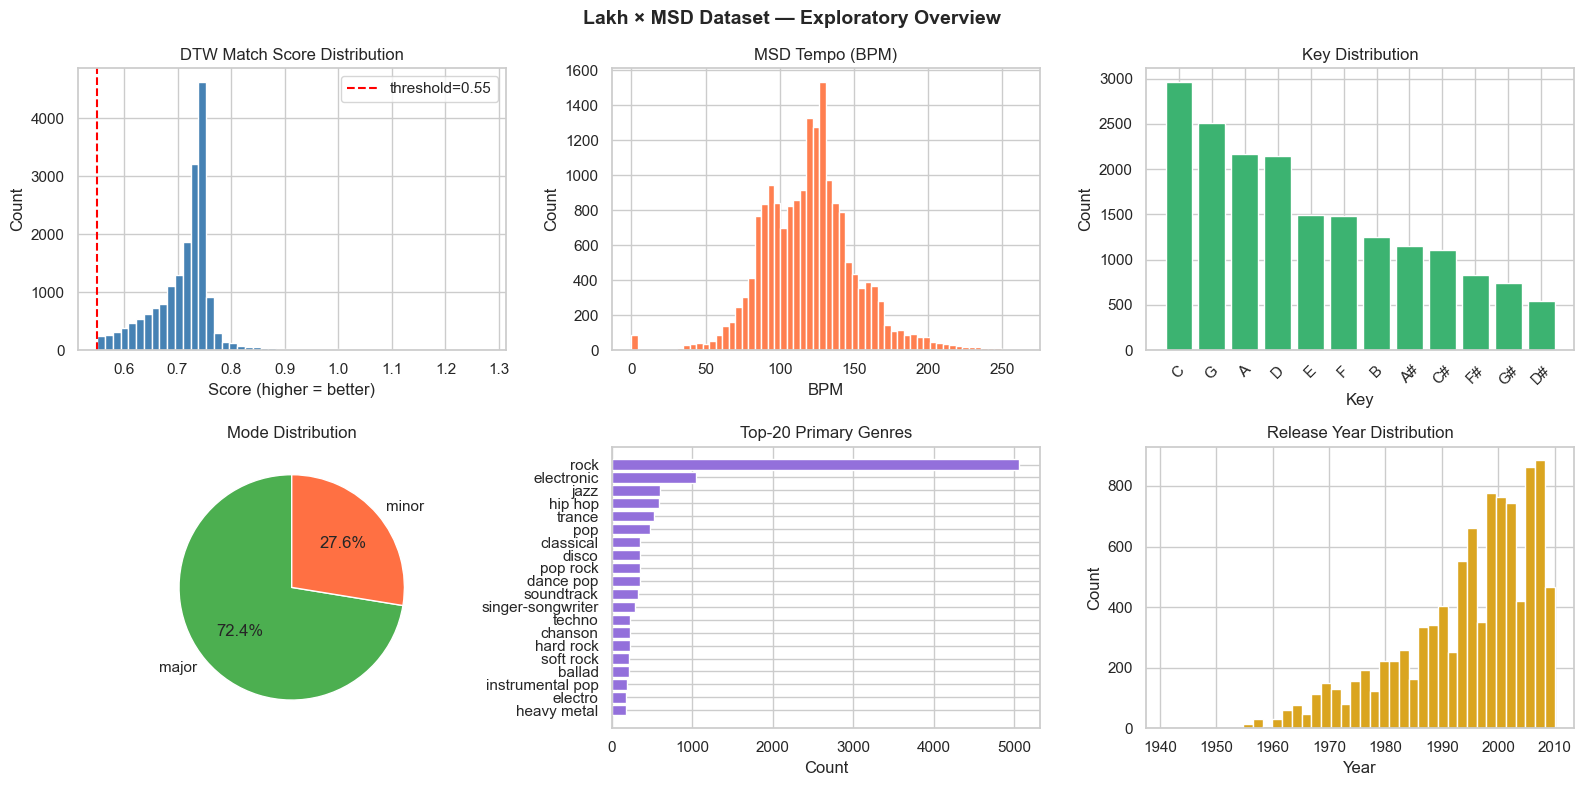

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Lakh × MSD Dataset — Exploratory Overview', fontsize=14, fontweight='bold')

# 1. Match score distribution
ax = axes[0, 0]
ax.hist(df['match_score'].dropna(), bins=50, color='steelblue', edgecolor='white')
ax.set(title='DTW Match Score Distribution', xlabel='Score (higher = better)', ylabel='Count')
ax.axvline(MIN_SCORE, color='red', linestyle='--', label=f'threshold={MIN_SCORE}')
ax.legend()

# 2. Tempo
ax = axes[0, 1]
ax.hist(df['msd_tempo'].dropna(), bins=60, color='coral', edgecolor='white')
ax.set(title='MSD Tempo (BPM)', xlabel='BPM', ylabel='Count')

# 3. Key distribution
ax = axes[0, 2]
key_counts = df['key_name'].value_counts()
ax.bar(key_counts.index, key_counts.values, color='mediumseagreen')
ax.set(title='Key Distribution', xlabel='Key', ylabel='Count')
ax.tick_params(axis='x', rotation=45)

# 4. Mode (major / minor)
ax = axes[1, 0]
mode_counts = df['mode_name'].value_counts()
ax.pie(mode_counts.values, labels=mode_counts.index, autopct='%1.1f%%',
       colors=['#4CAF50', '#FF7043'], startangle=90)
ax.set_title('Mode Distribution')

# 5. Top-20 genres
ax = axes[1, 1]
genre_counts = df['primary_genre'].dropna().value_counts().head(20)
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1], color='mediumpurple')
ax.set(title='Top-20 Primary Genres', xlabel='Count')

# 6. Year distribution
ax = axes[1, 2]
years = df['year'].dropna()
years = years[(years > 1900) & (years <= 2023)]
ax.hist(years, bins=40, color='goldenrod', edgecolor='white')
ax.set(title='Release Year Distribution', xlabel='Year', ylabel='Count')

plt.tight_layout()
plt.show()

In [9]:
print("=== Numeric summary ===")
num_cols = ['match_score','msd_tempo','msd_duration','msd_loudness',
            'msd_danceability','msd_energy','key_confidence','mode_confidence']
df[num_cols].describe().round(3)

=== Numeric summary ===


,match_score,msd_tempo,msd_duration,msd_loudness,msd_danceability,msd_energy,key_confidence,mode_confidence
count,18383.000,18383.000,18383.000,18383.000,18383.0,18383.0,18383.000,18383.000
mean,0.712,120.147,248.227,-10.599,0.0,0.0,0.501,0.529
std,0.059,31.735,100.616,5.482,0.0,0.0,0.279,0.194
min,0.550,0.000,0.626,-43.136,0.0,0.0,0.000,0.000
25%,0.684,98.190,192.143,-12.953,0.0,0.0,0.295,0.414
50%,0.728,120.514,233.195,-9.308,0.0,0.0,0.529,0.543
75%,0.745,136.998,283.650,-6.790,0.0,0.0,0.709,0.663
max,1.276,262.183,2149.329,-0.205,0.0,0.0,1.000,1.000


## 4 — Save processed dataset

In [10]:
df.to_parquet(OUT_PARQUET, index=False)
print(f"Saved {len(df):,} rows → {OUT_PARQUET}")

# also save a lighter CSV (without list columns) for quick inspection
csv_cols = [c for c in df.columns if not isinstance(df[c].iloc[0], list)]
df[csv_cols].to_csv(OUT_PARQUET.with_suffix('.csv'), index=False)
print("CSV saved (no list columns).")

Saved 18,383 rows → ..\data\processed\lakh_msd_dataset.parquet
CSV saved (no list columns).
